In [ ]:
from typing import Dict, TypedDict, List

import random
from langgraph.graph import StateGraph, START, END

In [ ]:
class GameState(TypedDict):
    low: int
    high: int
    guess: int
    secret: int
    attempts: int
    hint: str
    status: str

In [3]:
def setup_node(state: GameState):
    state["low"] = 1
    state["high"] = 100
    state["attempts"] = 0
    state["status"] = "Playing"
    return state

In [4]:
def ai_guess_node(state: GameState):
    state["guess"] = (state["low"] + state["high"]) // 2
    state["attempts"] += 1
    print(f"AI guesses: {state['guess']}")
    return state

In [5]:
def hint_node(state: GameState):

    hint = input("Too High / Too Low / Correct : ").lower()

    state["hint"] = hint

    if hint == "too high":
        state["high"] = state["guess"] - 1

    elif hint == "too low":
        state["low"] = state["guess"] + 1

    elif hint == "correct":
        state["status"] = "Won"

    return state

In [6]:
def should_continue(state: GameState):

    if state["hint"] == "correct":
        return "end"

    return "continue"

In [7]:
graph = StateGraph(GameState)

# Add nodes
graph.add_node("setup", setup_node)
graph.add_node("ai_guess", ai_guess_node)
graph.add_node("hint", hint_node)

# Add normal edges
graph.add_edge(START, "setup")
graph.add_edge("setup", "ai_guess")
graph.add_edge("ai_guess", "hint")

# Add conditional edge
graph.add_conditional_edges(
    "hint",
    should_continue,
    {
        "continue": "ai_guess",
        "end": END,
    },
)

# Compile the graph
app = graph.compile()

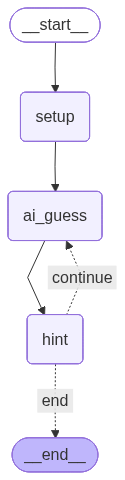

In [8]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke(
    {
        "low": 0,
        "high": 0,
        "guess": 0,
        "secret": 0,
        "attempts": 0,
        "hint": "",
        "status": ""
    }
)

print(result)

AI guesses: 50
